In [24]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter, NullFormatter, ScalarFormatter
import numpy as np
import pandas as pd
import seaborn as sb
import seaborn.objects as so


In [ ]:

all = pd.read_csv("../corr.csv", skip_blank_lines=True)
ldc = pd.read_csv("../corr2.csv", skip_blank_lines=True)
ldc2 = pd.read_csv("../corr3.csv", skip_blank_lines=True)
ldc3 = pd.read_csv("../corr4.csv", skip_blank_lines=True)


In [ ]:
mapping

In [25]:
df = pd.read_csv("../results/batchedFace.csv", skip_blank_lines=True)
df["workgroups"] = df["variant"].apply(lambda v: int(v.split("-")[0][2:]))
df["threads"] = [int(x.split("-")[1]) if x.split("-")[1] != "maximum" else 262144*2 for x in df["variant"]]
mapping = {w:i for i,w in enumerate(sorted(df["workgroups"].unique()))}
df["xticks"] = df["workgroups"].apply(lambda w: mapping[w])
df["cells"] = 6517376
df["ms_normed"] = df["time_mean_ms"] / df["cells"]

In [26]:
group_cols = [
    "case_long",
    "strategy",
    "language",
    "precision",
    "executor",
    "use_kernelAbstractions",
    "use_fusing",
]

baseline = (
    df[df["threads"] == 8192]
    .groupby(group_cols, as_index=False)["time_mean_ms"]
    .first()
    .rename(columns={"time_mean_ms": "serial_time"})
)

df = df.merge(baseline, on=group_cols, how="left")
df["speedup"] = df["serial_time"] / df["time_mean_ms"]
df["efficiency"] = df["speedup"] / (df["threads"]/8192)
df["efficiency"] = [min(x, 1.0) for x in df["efficiency"]]
threadmapping = {w:i for i,w in enumerate(sorted(df["threads"].unique()))}
df["threadticks"] = df["threads"].apply(lambda w: threadmapping[w])


4


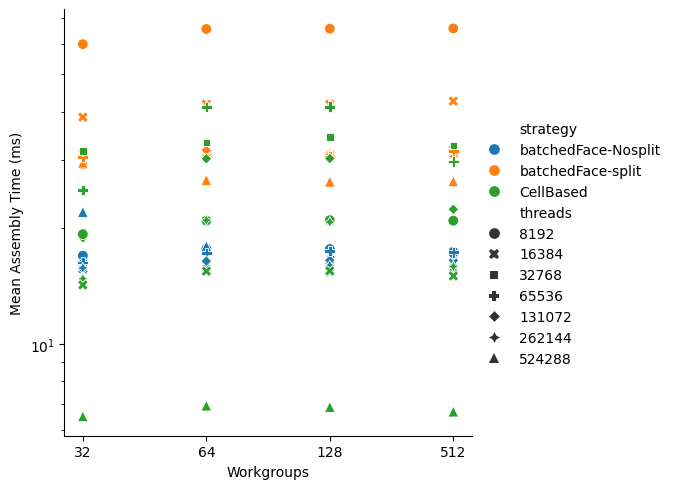

In [32]:
plot = sb.relplot(data=df, x="xticks", y="time_mean_ms",style="threads", hue="strategy", s=60)
print(len(df["workgroups"].unique()))
for ax in plot.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(labels=mapping.keys())
    ax.set(xlabel="Workgroups")
    ax.set(ylabel="Mean Assembly Time (ms)")
    ax.set_yscale("log")

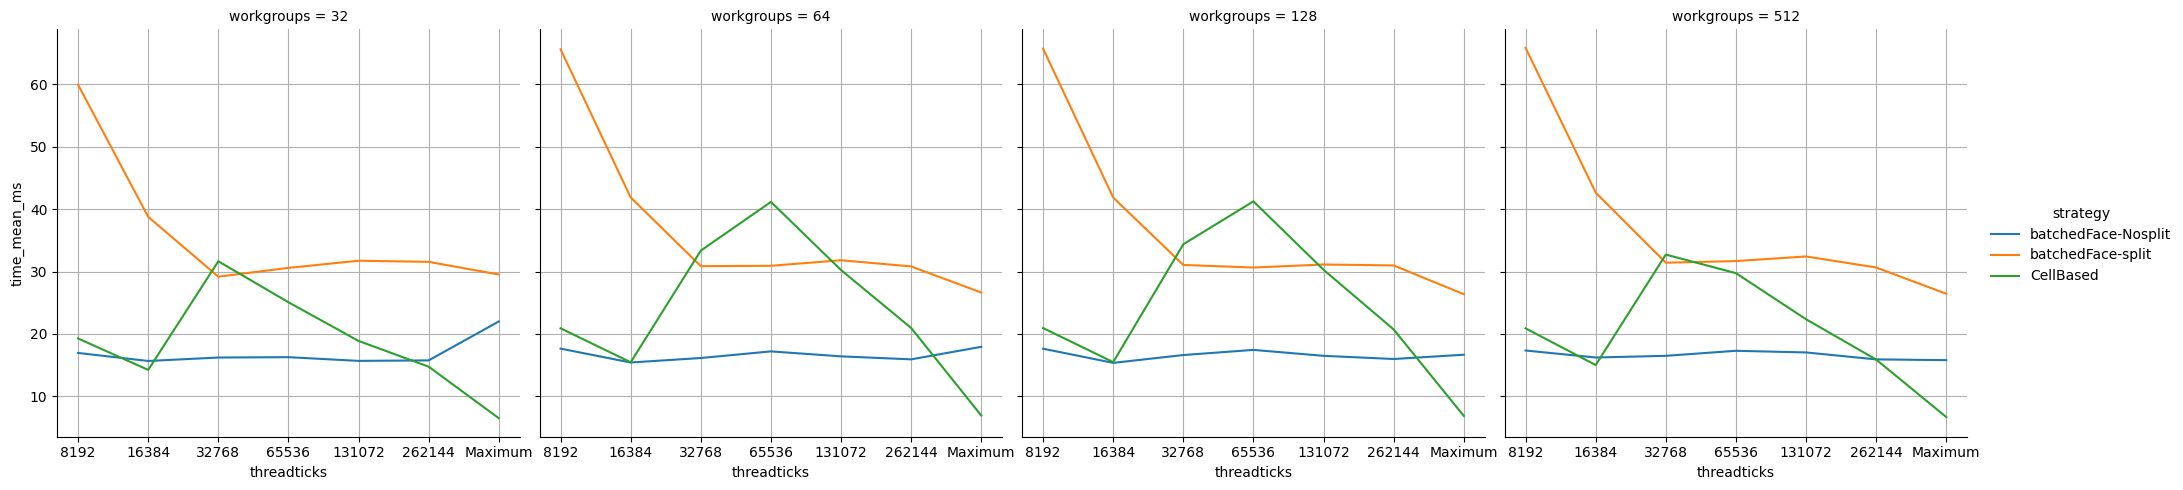

In [28]:
plot = sb.relplot(data=df, x="threadticks", y="time_mean_ms", hue="strategy", col="workgroups", kind="line")
for ax in plot.axes.flat:
    ax.set_xticks([0, 1, 2, 3, 4, 5, 6])
    ax.grid(True)
    ax.set_xticklabels([x if x <= 262144 else "Maximum" for x in sorted(df["threads"].unique()) ])

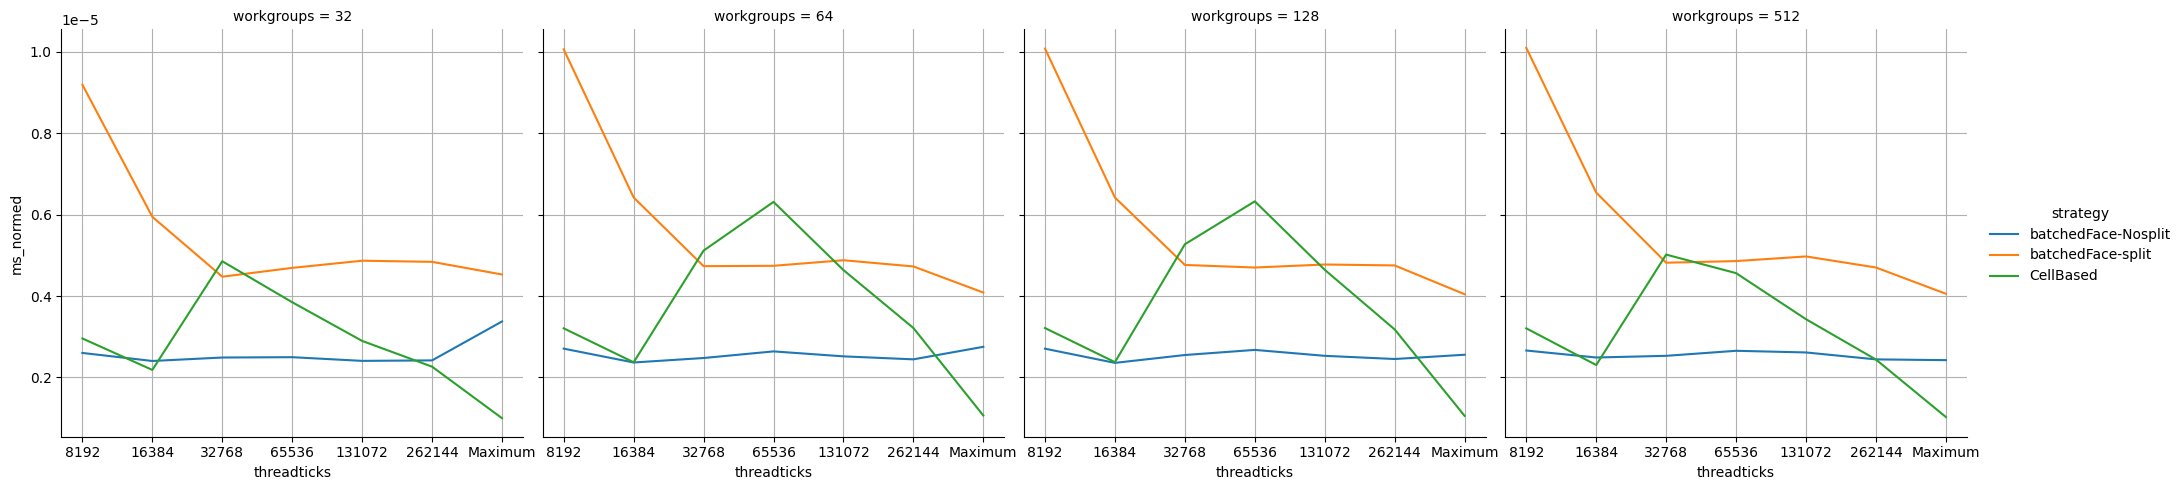

In [29]:
plot = sb.relplot(data=df, x="threadticks", y="ms_normed", hue="strategy", col="workgroups", kind="line")
for ax in plot.axes.flat:
    ax.set_xticks([0, 1, 2, 3, 4, 5, 6])
    ax.grid(True)
    ax.set_xticklabels([x if x <= 262144 else "Maximum" for x in sorted(df["threads"].unique()) ])

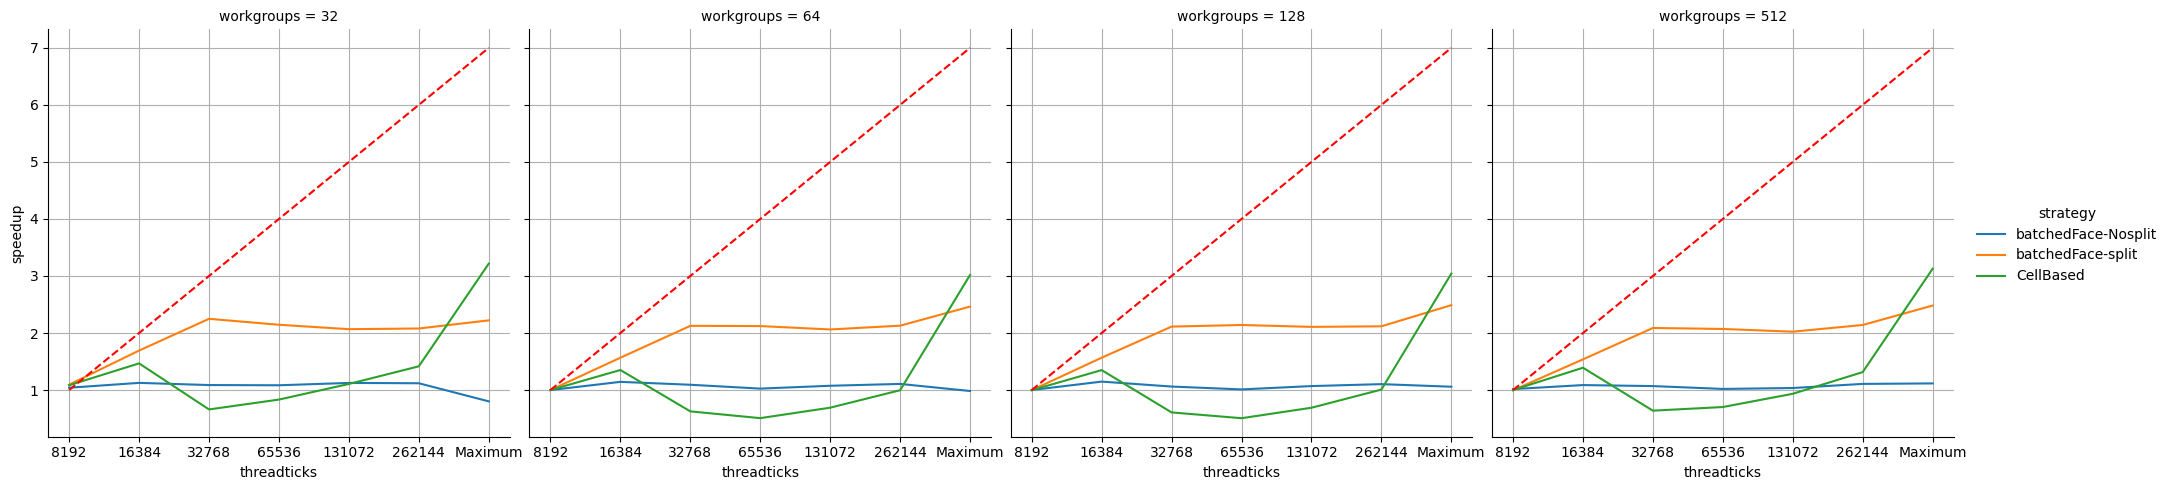

In [30]:
plot = sb.relplot(data=df, x="threadticks", y="speedup", hue="strategy", col="workgroups", kind="line")
for ax in plot.axes.flat:
    ax.set_xticks([0, 1, 2, 3, 4, 5, 6])
    ax.plot([0, 6], [1,7], c="r", linestyle="--")
    ax.grid(True)
    ax.set_xticklabels([x if x <= 262144 else "Maximum" for x in sorted(df["threads"].unique()) ])

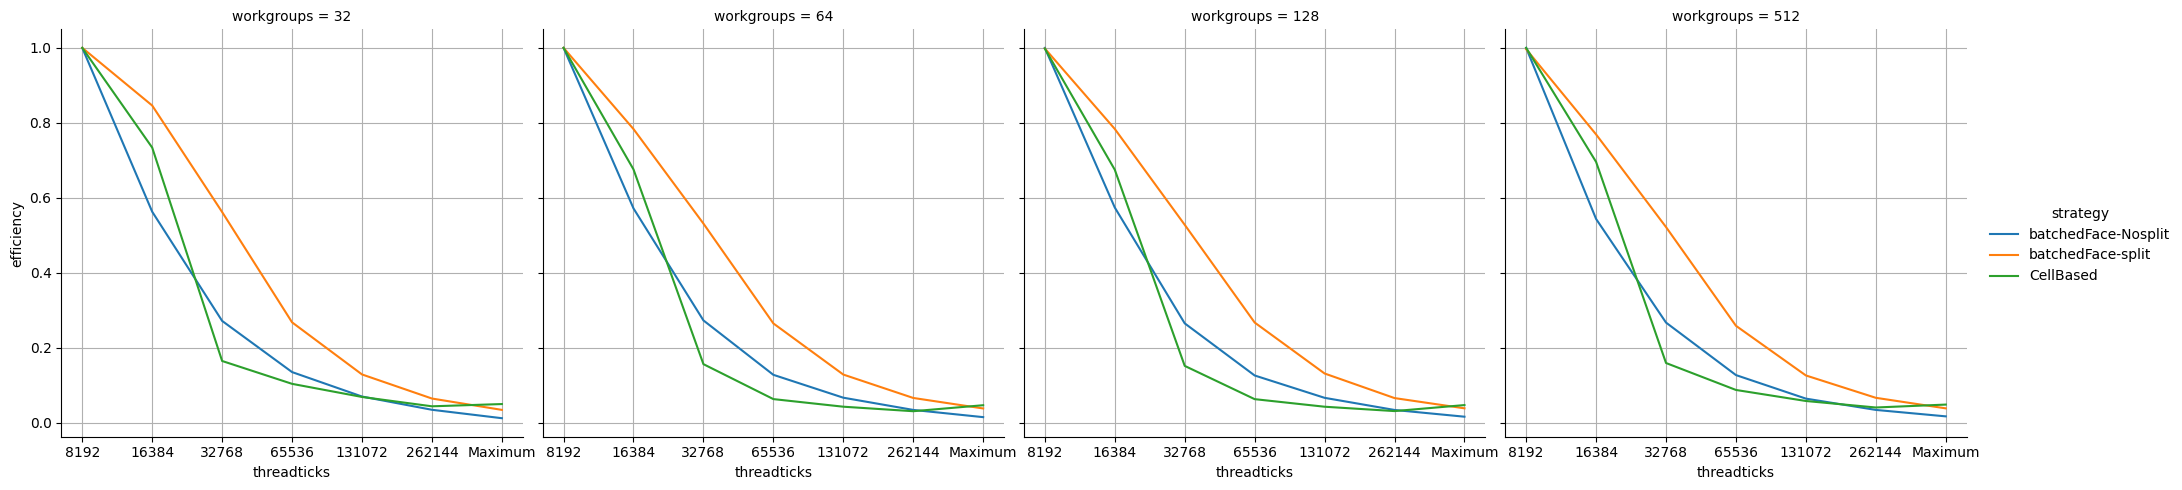

In [31]:
plot = sb.relplot(data=df, x="threadticks", y="efficiency", hue="strategy", col="workgroups", kind="line")
for ax in plot.axes.flat:
    ax.set_xticks([0, 1, 2, 3, 4, 5, 6])
    ax.grid(True)
    ax.set_xticklabels([x if x <= 262144 else "Maximum" for x in sorted(df["threads"].unique()) ])

In [ ]:
pivot_df = all.pivot(index='blocksize', columns='workgroupsize', values='time')
ldcpivot_df = ldc.pivot(index='blocksize', columns='workgroupsize', values='time')
ldc2pivot_df = ldc2.pivot(index='blocksize', columns='workgroupsize', values='time')

In [ ]:
f, axes = plt.subplots(2,2, figsize=(15, 20))
wb = axes.flat[0]
ldc = axes.flat[1]
ldc2 = axes.flat[2]
ldc3 = axes.flat[3]
p1 = sb.heatmap(pivot_df,annot=True, square=True, ax = wb)  # no color specified
p1.set(title="Windsorbody, merged")
p2 = sb.heatmap(ldcpivot_df,annot=True, square=True, ax = ldc)  # no color specified
p2.set(title="LDC, merged")
p3 = sb.heatmap(ldc2pivot_df,annot=True, square=True, ax = ldc2)  # no color specified
p3.set(title="LDC, default")
p4 = sb.heatmap(ldc3pivot_df,annot=True, square=True, ax = ldc3)  # no color specified
p4.set(title="LDC, default")
plt.tight_layout()

In [ ]:
ldc3

In [ ]:
ldc3["multBy"] = ldc3["workgroupsize"] / ldc3["blocksize"]

In [ ]:
ldc3pivot_df = ldc3.pivot(index='blocksize', columns='multBy', values='time')


In [ ]:
f, axes = plt.subplots(figsize=(10, 10))
p = sb.heatmap(ldc3pivot_df,annot=True)  # no color specified
# p.set_xticklabels(ldc3["workgroupsize"].unique())
plt.tight_layout()


In [ ]:
ldc3

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter, NullFormatter, ScalarFormatter
import numpy as np
import pandas as pd
import seaborn as sb
import seaborn.objects as so
import math


df = pd.read_csv("../test.csv", skip_blank_lines=True)
df["cells"] = [int(x.rsplit("/", 2)[1])**3 for x in df["case_long"]]
df["ms_normed"] = df["time_mean_ms"] / df["cells"]
strategies = list(df["strategy"].unique())


sb.set_theme()


In [ ]:
plot = sb.relplot(data=df, x="cells", kind="line", y="time_mean_ms")
plot.set(title="Assembly Time")
plot = sb.relplot(data=df, x="cells", kind="scatter", y="ms_normed")
plot.set(title="Assembly Time Normed Per Cell")



In [ ]:
plot = sb.relplot(data=df, x="cells", kind="scatter", y="ms_normed")
plot.set(title="Assembly Time per Cell")
axes = plot.axes.flat


In [ ]:
df